In [1]:
# ==========================================================
# SECTION 1: Configuration (VOCALIS v3.0)
# ==========================================================
#
# Single source of truth for paths and hyperparameters.
# Every later section reads from this CONFIG dict -- nothing
# is hardcoded elsewhere.
# ==========================================================

from pathlib import Path

CONFIG = {
    # ---- Environment ----
    "root_dir": Path(r"D:\vocalis_3.0"),
    "random_seed": 42,
    "device": "cpu",

    # ---- Piper (local Windows binary, not pip package) ----
    "piper_exe": Path(r"D:\vocalis_3.0\piper\piper.exe"),
    "piper_voice_model": Path(r"D:\vocalis_3.0\piper\voices\en_US-lessac-medium.onnx"),

    # ---- Dataset ----
    "vctk_url": "https://datashare.ed.ac.uk/bitstream/handle/10283/3443/VCTK-Corpus-0.92.zip",
    "n_speakers": 40,
    "n_train_speakers": 28,
    "n_val_speakers": 6,
    "n_test_speakers": 6,
    "utterances_per_speaker": 45,

    # ---- Speaker Encoder ----
    "encoder_name": "ecapa",  # "ecapa" (primary) or "resemblyzer" (ablation)
    # embedding_dim is intentionally NOT hardcoded here -- it is derived
    # from the loaded encoder at runtime in Section 4. This was a latent
    # bug in v2.0.2 (hardcoded independent of the active encoder).

    # ---- VOCALIS Adapter ----
    "hidden_dim": 512,
    "dropout": 0.1,

    # ---- Training ----
    "batch_size": 16,
    "epochs": 50,
    "learning_rate": 1e-3,
    "loss_weights": {
        "cosine": 1.0,
        "mse": 0.5,
        "regularization": 0.1
    },
}

# ---- Derived paths (built from root_dir, not re-typed elsewhere) ----
CONFIG["vctk_root"] = CONFIG["root_dir"] / "data" / "raw" / "VCTK"
CONFIG["vctk_zip"] = CONFIG["root_dir"] / "data" / "raw" / "VCTK-Corpus-0.92.zip"
CONFIG["synthetic_audio_dir"] = CONFIG["root_dir"] / "data" / "synthetic"
CONFIG["natural_embedding_dir"] = CONFIG["root_dir"] / "data" / "embeddings" / "natural"
CONFIG["synthetic_embedding_dir"] = CONFIG["root_dir"] / "data" / "embeddings" / "synthetic"
CONFIG["metadata_path"] = CONFIG["root_dir"] / "data" / "metadata" / "vocalis_metadata.csv"
CONFIG["checkpoint_dir"] = CONFIG["root_dir"] / "models" / "checkpoints"
CONFIG["results_dir"] = CONFIG["root_dir"] / "results"

# ---- Create directory structure ----
for path in [
    CONFIG["root_dir"] / "data" / "raw",
    CONFIG["synthetic_audio_dir"],
    CONFIG["natural_embedding_dir"],
    CONFIG["synthetic_embedding_dir"],
    CONFIG["metadata_path"].parent,
    CONFIG["checkpoint_dir"],
    CONFIG["results_dir"] / "figures",
    CONFIG["results_dir"] / "metrics",
]:
    path.mkdir(parents=True, exist_ok=True)

print("CONFIG loaded. Root directory:", CONFIG["root_dir"])
print("Directory structure created/verified.")

# Sanity check: Piper binary and voice model exist where CONFIG expects them
assert CONFIG["piper_exe"].exists(), f"Piper executable not found at {CONFIG['piper_exe']} -- update the path in CONFIG."
assert CONFIG["piper_voice_model"].exists(), f"Piper voice model not found at {CONFIG['piper_voice_model']} -- update the path in CONFIG."
print("Piper binary and voice model paths verified.")

CONFIG loaded. Root directory: D:\vocalis_3.0
Directory structure created/verified.
Piper binary and voice model paths verified.


In [2]:
# ==========================================================
# SECTION 2: VCTK Dataset Preparation (VOCALIS v3.0)
# ==========================================================
#
# Downloads VCTK, builds a speaker-disjoint train/val/test
# split, and writes the metadata CSV every later section
# reads from.
#
# Requires Section 1 (CONFIG) to have run first.
# ==========================================================

import random
import zipfile
import pandas as pd
import requests
from tqdm import tqdm

random.seed(CONFIG["random_seed"])

# ----------------------------------------------------------
# Download VCTK (streamed, with progress bar)
# ----------------------------------------------------------
# Full corpus is ~11GB zipped. This will take a while depending
# on your connection -- it's a one-time cost, the script skips
# this step on future runs if the zip or extracted folder
# already exists.

VCTK_ROOT = CONFIG["vctk_root"]
VCTK_ZIP = CONFIG["vctk_zip"]
VCTK_AUDIO_DIR = VCTK_ROOT / "wav48_silence_trimmed"
VCTK_TXT_DIR = VCTK_ROOT / "txt"

if VCTK_ROOT.exists() and any(VCTK_ROOT.iterdir()):
    print(f"VCTK already extracted at {VCTK_ROOT}, skipping download/extraction.")
else:
    if not VCTK_ZIP.exists():
        print(f"Downloading VCTK corpus to {VCTK_ZIP} ...")
        print("This is ~11GB -- expect this to take a while.")

        response = requests.get(CONFIG["vctk_url"], stream=True)
        response.raise_for_status()
        total_size = int(response.headers.get("content-length", 0))

        with open(VCTK_ZIP, "wb") as f, tqdm(
            total=total_size, unit="B", unit_scale=True, desc="VCTK download"
        ) as progress_bar:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                progress_bar.update(len(chunk))

        print("Download complete.")
    else:
        print(f"Zip already present at {VCTK_ZIP}, skipping download.")

    print(f"Extracting to {VCTK_ROOT} ...")
    VCTK_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(VCTK_ZIP, "r") as zip_ref:
        zip_ref.extractall(VCTK_ROOT)
    print("Extraction complete.")

# ----------------------------------------------------------
# Speaker Selection (speaker-disjoint, gender-balanced)
# ----------------------------------------------------------

SPEAKER_INFO_PATH = VCTK_ROOT / "speaker-info.txt"

if not SPEAKER_INFO_PATH.exists():
    raise FileNotFoundError(
        f"speaker-info.txt not found at {SPEAKER_INFO_PATH}. "
        f"Check the extracted VCTK folder structure -- it may have "
        f"extracted one level deeper than expected (e.g. a nested "
        f"'VCTK-Corpus-0.92' folder). List the contents of {VCTK_ROOT} "
        f"and tell me what you see if this happens."
    )

# NOTE: REGION often contains multiple words (e.g. "Southern England"),
# which breaks a naive fixed-5-column whitespace split -- rows with a
# multi-word region produce >5 fields and get silently dropped. We parse
# line-by-line with maxsplit=4 instead: the first 4 whitespace-separated
# tokens become ID/AGE/GENDER/ACCENTS, and everything remaining on the
# line (however many words) becomes REGION as one string.
#
# NOTE: the ID column already includes the "p" prefix (e.g. "p225") --
# earlier code incorrectly prepended an extra "p", producing "pp225".
# Fixed here: use the parsed ID as-is.
#
# NOTE: some VCTK speaker-info.txt files have trailing license/notes
# text below the actual speaker rows. We validate each parsed ID against
# a strict p<number> pattern and skip/report anything that doesn't match,
# rather than silently accepting garbage rows.
import re

speaker_records = []
skipped_lines = []

with open(SPEAKER_INFO_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()[1:]  # skip header row

for line in lines:
    line = line.strip()
    if not line:
        continue
    parts = line.split(maxsplit=4)
    if len(parts) < 3:
        skipped_lines.append(line)
        continue

    speaker_id, age, gender = parts[0], parts[1], parts[2]

    if not re.match(r"^p\d+$", speaker_id):
        skipped_lines.append(line)
        continue

    region = parts[4] if len(parts) > 4 else (parts[3] if len(parts) > 3 else "")
    speaker_records.append({
        "speaker_id": speaker_id,  # already includes "p" prefix, used as-is
        "age": age,
        "gender": gender,
        "region": region
    })

speaker_info = pd.DataFrame(speaker_records)

print(f"Parsed {len(speaker_info)} valid speakers from speaker-info.txt")
if skipped_lines:
    print(f"Skipped {len(skipped_lines)} non-speaker line(s):")
    for s in skipped_lines[:5]:
        print(f"  {s!r}")

assert len(speaker_info) > 0, "Speaker info parsing produced 0 rows -- check file format manually."

males = speaker_info[speaker_info["gender"] == "M"]["speaker_id"].tolist()
females = speaker_info[speaker_info["gender"] == "F"]["speaker_id"].tolist()

random.shuffle(males)
random.shuffle(females)

n_each = CONFIG["n_speakers"] // 2
selected_speakers = males[:n_each] + females[:n_each]
random.shuffle(selected_speakers)

# ----------------------------------------------------------
# Speaker-Disjoint Split
# ----------------------------------------------------------
# CRITICAL: split by speaker, never by utterance. Enforced here,
# before any embeddings exist, so no downstream code can violate it.

n_train = CONFIG["n_train_speakers"]
n_val = CONFIG["n_val_speakers"]
n_test = CONFIG["n_test_speakers"]
assert n_train + n_val + n_test == CONFIG["n_speakers"], \
    "n_train + n_val + n_test must equal n_speakers in CONFIG"

train_speakers = selected_speakers[:n_train]
val_speakers = selected_speakers[n_train:n_train + n_val]
test_speakers = selected_speakers[n_train + n_val:]

split_map = {}
for s in train_speakers:
    split_map[s] = "train"
for s in val_speakers:
    split_map[s] = "val"
for s in test_speakers:
    split_map[s] = "test"

print(f"Train speakers ({len(train_speakers)}): {train_speakers}")
print(f"Val speakers   ({len(val_speakers)}): {val_speakers}")
print(f"Test speakers  ({len(test_speakers)}): {test_speakers}")

# Sanity check: no speaker appears in more than one split
all_selected = set(train_speakers) | set(val_speakers) | set(test_speakers)
assert len(all_selected) == len(selected_speakers), "Speaker overlap detected between splits!"

# ----------------------------------------------------------
# Build Metadata (utterance level)
# ----------------------------------------------------------

records = []

for speaker_id in selected_speakers:

    speaker_audio_dir = VCTK_AUDIO_DIR / speaker_id
    speaker_txt_dir = VCTK_TXT_DIR / speaker_id

    if not speaker_txt_dir.exists():
        print(f"WARNING: no transcript dir for {speaker_id}, skipping.")
        continue

    txt_files = sorted(speaker_txt_dir.glob("*.txt"))[:CONFIG["utterances_per_speaker"]]

    for txt_file in txt_files:

        utterance_id = txt_file.stem  # e.g. p225_001

        # VCTK-0.92 stores mic1/mic2 recordings; use mic1
        audio_candidates = list(speaker_audio_dir.glob(f"{utterance_id}_mic1.flac"))

        if not audio_candidates:
            continue

        natural_audio_path = audio_candidates[0]

        with open(txt_file, "r", encoding="utf-8") as f:
            transcript = f.read().strip()

        records.append({
            "speaker_id": speaker_id,
            "utterance_id": utterance_id,
            "transcript": transcript,
            "natural_audio_path": str(natural_audio_path),
            "synthetic_audio_path": "",    # filled in Section 3 (Piper synthesis)
            "natural_embedding_path": "",  # filled in Section 4 (embedding extraction)
            "synthetic_embedding_path": "",
            "dataset_split": split_map[speaker_id]
        })

metadata_df = pd.DataFrame(records)
metadata_df.to_csv(CONFIG["metadata_path"], index=False)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("=" * 60)
print("VOCALIS Dataset Metadata Summary")
print("=" * 60)
print(f"Total utterances : {len(metadata_df)}")
print(metadata_df["dataset_split"].value_counts())
print(f"\nMetadata saved to: {CONFIG['metadata_path']}")
print("=" * 60)

VCTK already extracted at D:\vocalis_3.0\data\raw\VCTK, skipping download/extraction.
Parsed 109 valid speakers from speaker-info.txt
Skipped 1 non-speaker line(s):
  's5    22  F    British (new speaker, more data would be released for training a speaker-dependent model)'
Train speakers (28): ['p228', 'p239', 'p244', 'p251', 'p288', 'p280', 'p252', 'p292', 'p287', 'p311', 'p278', 'p254', 'p286', 'p329', 'p275', 'p302', 'p282', 'p230', 'p295', 'p241', 'p360', 'p301', 'p277', 'p270', 'p225', 'p255', 'p249', 'p376']
Val speakers   (6): ['p294', 'p326', 'p273', 'p285', 'p237', 'p307']
Test speakers  (6): ['p257', 'p253', 'p340', 'p351', 'p317', 'p281']
VOCALIS Dataset Metadata Summary
Total utterances : 1800
dataset_split
train    1260
val       270
test      270
Name: count, dtype: int64

Metadata saved to: D:\vocalis_3.0\data\metadata\vocalis_metadata.csv


In [3]:
# ==========================================================
# SECTION 3: Synthetic Speech Generation (Piper)
# ==========================================================
#
# For every utterance in the metadata CSV, synthesizes the
# transcript through Piper and saves the resulting audio,
# mirroring VCTK's speaker-folder structure under
# data/synthetic/. Writes the output path back into metadata.
#
# Requires Sections 1 (CONFIG) and 2 (metadata CSV) to have
# run first.
# ==========================================================

import subprocess
import pandas as pd
from tqdm import tqdm

metadata_df = pd.read_csv(CONFIG["metadata_path"])

# ----------------------------------------------------------
# Synthesize each utterance's transcript through Piper
# ----------------------------------------------------------

synthetic_paths = []
failures = []

for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Piper synthesis"):

    speaker_dir = CONFIG["synthetic_audio_dir"] / row["speaker_id"]
    speaker_dir.mkdir(parents=True, exist_ok=True)

    output_path = speaker_dir / f"{row['utterance_id']}_synthetic.wav"

    # Skip if already synthesized (idempotent -- safe to re-run this cell)
    if output_path.exists():
        synthetic_paths.append(str(output_path))
        continue

    transcript = str(row["transcript"])

    try:
        result = subprocess.run(
            [
                str(CONFIG["piper_exe"]),
                "-m", str(CONFIG["piper_voice_model"]),
                "-f", str(output_path)
            ],
            input=transcript,
            text=True,
            capture_output=True,
            timeout=60
        )

        if result.returncode != 0 or not output_path.exists():
            failures.append((row["utterance_id"], result.stderr))
            synthetic_paths.append("")
        else:
            synthetic_paths.append(str(output_path))

    except subprocess.TimeoutExpired:
        failures.append((row["utterance_id"], "TIMEOUT"))
        synthetic_paths.append("")

metadata_df["synthetic_audio_path"] = synthetic_paths
metadata_df.to_csv(CONFIG["metadata_path"], index=False)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

n_success = sum(1 for p in synthetic_paths if p)
n_failed = len(failures)

print("=" * 60)
print("Piper Synthesis Summary")
print("=" * 60)
print(f"Succeeded : {n_success} / {len(metadata_df)}")
print(f"Failed    : {n_failed}")

if failures:
    print("\nFirst few failures:")
    for utterance_id, error in failures[:5]:
        print(f"  {utterance_id}: {error}")
    print(
        "\nIf failures are widespread, paste me one full error message "
        "-- likely a path issue or a transcript containing characters "
        "Piper's phonemizer doesn't handle well."
    )

print("=" * 60)

Piper synthesis: 100%|██████████| 1800/1800 [00:00<00:00, 3099.43it/s]

Piper Synthesis Summary
Succeeded : 1800 / 1800
Failed    : 0


In [4]:
# ==========================================================
# SECTION 4: Speaker Embedding Extraction
# ==========================================================
#
# Extracts speaker embeddings for both natural (VCTK) and
# synthetic (Piper) audio, using whichever encoder is set in
# CONFIG["encoder_name"] ("ecapa" or "resemblyzer").
#
# Embeddings are cached to disk as .npy files -- extracted
# once here, never recomputed inside the training loop.
#
# CRITICAL: embedding_dim is derived from the loaded encoder
# at runtime, not hardcoded in CONFIG. This fixes a latent
# bug from v2.0.2 where embedding_dim was set independently
# of which encoder was actually active.
#
# Requires Sections 1 (CONFIG) and 2 (metadata CSV) to have
# run first. Synthetic embeddings additionally require
# Section 3 to have completed.
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torchaudio
from tqdm import tqdm

metadata_df = pd.read_csv(CONFIG["metadata_path"])

# ----------------------------------------------------------
# Encoder Loading (dispatches on CONFIG["encoder_name"])
# ----------------------------------------------------------

ENCODER_NAME = CONFIG["encoder_name"]
TARGET_SR = 16000  # both ECAPA-TDNN and Resemblyzer expect 16kHz input

if ENCODER_NAME == "ecapa":
    from speechbrain.inference.speaker import EncoderClassifier

    print("Loading ECAPA-TDNN (speechbrain/spkrec-ecapa-voxceleb)...")
    print("First run downloads the pretrained model (~80MB) -- one-time cost.")

    _ecapa_model = EncoderClassifier.from_hparams(
        source="speechbrain/spkrec-ecapa-voxceleb",
        savedir=str(CONFIG["root_dir"] / "models" / "pretrained" / "ecapa"),
        run_opts={"device": CONFIG["device"]}
    )

    def extract_embedding(audio_path):
        """Returns a 1D numpy embedding for the given audio file."""
        signal, sr = torchaudio.load(str(audio_path))
        if signal.shape[0] > 1:
            signal = signal.mean(dim=0, keepdim=True)  # mono
        if sr != TARGET_SR:
            signal = torchaudio.functional.resample(signal, sr, TARGET_SR)
        with torch.no_grad():
            embedding = _ecapa_model.encode_batch(signal)
        return embedding.squeeze().cpu().numpy()

    # Derive embedding_dim from the actual encoder output -- not hardcoded.
    _dummy_signal = torch.zeros(1, TARGET_SR)  # 1 second of silence
    with torch.no_grad():
        _dummy_embedding = _ecapa_model.encode_batch(_dummy_signal)
    CONFIG["embedding_dim"] = _dummy_embedding.squeeze().shape[0]

elif ENCODER_NAME == "resemblyzer":
    from resemblyzer import VoiceEncoder, preprocess_wav

    print("Loading Resemblyzer voice encoder...")
    _resemblyzer_model = VoiceEncoder(device=CONFIG["device"])

    def extract_embedding(audio_path):
        """Returns a 1D numpy embedding for the given audio file."""
        wav = preprocess_wav(str(audio_path))
        return _resemblyzer_model.embed_utterance(wav)

    # Derive embedding_dim from the actual encoder output -- not hardcoded.
    CONFIG["embedding_dim"] = _resemblyzer_model.embed_utterance(
        np.zeros(TARGET_SR, dtype=np.float32)
    ).shape[0]

else:
    raise ValueError(f"Unknown encoder_name in CONFIG: {ENCODER_NAME!r}")

print(f"Encoder loaded: {ENCODER_NAME}, embedding_dim = {CONFIG['embedding_dim']}")

# ----------------------------------------------------------
# Extract & Cache Embeddings
# ----------------------------------------------------------

natural_embedding_paths = []
synthetic_embedding_paths = []
extraction_failures = []

synthetic_available = "synthetic_audio_path" in metadata_df.columns and \
    metadata_df["synthetic_audio_path"].notna().any() and \
    (metadata_df["synthetic_audio_path"] != "").any()

if not synthetic_available:
    print(
        "\nNOTE: synthetic_audio_path is empty for all rows -- Section 3 "
        "(Piper synthesis) hasn't run yet, or hasn't completed. This cell "
        "will extract NATURAL embeddings only and leave synthetic embedding "
        "paths blank. Re-run this section after Section 3 completes."
    )

for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc=f"Embeddings ({ENCODER_NAME})"):

    speaker_id = row["speaker_id"]
    utterance_id = row["utterance_id"]

    # ---- Natural embedding ----
    natural_out_dir = CONFIG["natural_embedding_dir"] / ENCODER_NAME / speaker_id
    natural_out_dir.mkdir(parents=True, exist_ok=True)
    natural_out_path = natural_out_dir / f"{utterance_id}.npy"

    if natural_out_path.exists():
        natural_embedding_paths.append(str(natural_out_path))
    else:
        try:
            emb = extract_embedding(row["natural_audio_path"])
            np.save(natural_out_path, emb)
            natural_embedding_paths.append(str(natural_out_path))
        except Exception as e:
            extraction_failures.append((utterance_id, "natural", str(e)))
            natural_embedding_paths.append("")

    # ---- Synthetic embedding (only if Section 3 has produced audio) ----
    synth_audio_path = row.get("synthetic_audio_path", "")
    if synthetic_available and isinstance(synth_audio_path, str) and synth_audio_path:
        synthetic_out_dir = CONFIG["synthetic_embedding_dir"] / ENCODER_NAME / speaker_id
        synthetic_out_dir.mkdir(parents=True, exist_ok=True)
        synthetic_out_path = synthetic_out_dir / f"{utterance_id}.npy"

        if synthetic_out_path.exists():
            synthetic_embedding_paths.append(str(synthetic_out_path))
        else:
            try:
                emb = extract_embedding(synth_audio_path)
                np.save(synthetic_out_path, emb)
                synthetic_embedding_paths.append(str(synthetic_out_path))
            except Exception as e:
                extraction_failures.append((utterance_id, "synthetic", str(e)))
                synthetic_embedding_paths.append("")
    else:
        synthetic_embedding_paths.append("")

metadata_df["natural_embedding_path"] = natural_embedding_paths
metadata_df["synthetic_embedding_path"] = synthetic_embedding_paths
metadata_df.to_csv(CONFIG["metadata_path"], index=False)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

n_natural_ok = sum(1 for p in natural_embedding_paths if p)
n_synthetic_ok = sum(1 for p in synthetic_embedding_paths if p)

print("=" * 60)
print("Embedding Extraction Summary")
print("=" * 60)
print(f"Encoder             : {ENCODER_NAME} (dim={CONFIG['embedding_dim']})")
print(f"Natural embeddings   : {n_natural_ok} / {len(metadata_df)}")
print(f"Synthetic embeddings : {n_synthetic_ok} / {len(metadata_df)}")
print(f"Failures             : {len(extraction_failures)}")

if extraction_failures:
    print("\nFirst few failures:")
    for utterance_id, kind, error in extraction_failures[:5]:
        print(f"  {utterance_id} ({kind}): {error}")

print("=" * 60)

d:\vocalis_3.0\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
torchvision is not available - cannot save figures


Loading ECAPA-TDNN (speechbrain/spkrec-ecapa-voxceleb)...
First run downloads the pretrained model (~80MB) -- one-time cost.
Encoder loaded: ecapa, embedding_dim = 192


Embeddings (ecapa): 100%|██████████| 1800/1800 [00:05<00:00, 337.89it/s]


Embedding Extraction Summary
Encoder             : ecapa (dim=192)
Natural embeddings   : 1800 / 1800
Synthetic embeddings : 1800 / 1800
Failures             : 0


In [5]:
# ==========================================================
# VERIFICATION CHECKPOINT (run after Section 4, before Section 5)
# ==========================================================
#
# Sanity-checks the metadata + embeddings produced by Sections
# 2-4 against the locked design spec, BEFORE building the
# training dataset on top of them. Catching a problem here is
# cheap; catching it after Section 7 (training) is expensive.
# ==========================================================

import numpy as np
import pandas as pd

metadata_df = pd.read_csv(CONFIG["metadata_path"])
errors = []
warnings = []

# ---- Check 1: No speaker appears in more than one split ----
speaker_splits = metadata_df.groupby("speaker_id")["dataset_split"].nunique()
violating_speakers = speaker_splits[speaker_splits > 1]
if len(violating_speakers) > 0:
    errors.append(f"LEAKAGE: speakers in multiple splits: {violating_speakers.index.tolist()}")
else:
    print("[OK] No speaker appears in more than one split.")

# ---- Check 2: Split sizes roughly match CONFIG ----
split_counts = metadata_df["dataset_split"].value_counts()
print(f"[INFO] Split counts: {split_counts.to_dict()}")

# ---- Check 3: Natural embeddings exist and are loadable ----
natural_paths = metadata_df["natural_embedding_path"].dropna()
natural_paths = natural_paths[natural_paths != ""]
if len(natural_paths) == 0:
    errors.append("No natural embeddings found -- did Section 4 run?")
else:
    sample_emb = np.load(natural_paths.iloc[0])
    print(f"[OK] Natural embeddings present ({len(natural_paths)} / {len(metadata_df)}), shape={sample_emb.shape}")
    if sample_emb.shape[0] != CONFIG.get("embedding_dim"):
        errors.append(
            f"Embedding dim mismatch: file has {sample_emb.shape[0]}, "
            f"CONFIG says {CONFIG.get('embedding_dim')}. Re-run Section 4."
        )

# ---- Check 4: Synthetic embeddings (only checked if Section 3 has run) ----
synthetic_paths = metadata_df["synthetic_embedding_path"].dropna()
synthetic_paths = synthetic_paths[synthetic_paths != ""]
if len(synthetic_paths) == 0:
    warnings.append(
        "No synthetic embeddings yet -- expected if Section 3 hasn't "
        "completed. Not an error, just not ready for Section 5 yet."
    )
else:
    sample_emb = np.load(synthetic_paths.iloc[0])
    print(f"[OK] Synthetic embeddings present ({len(synthetic_paths)} / {len(metadata_df)}), shape={sample_emb.shape}")
    if sample_emb.shape[0] != CONFIG.get("embedding_dim"):
        errors.append(
            f"Synthetic embedding dim ({sample_emb.shape[0]}) doesn't match "
            f"natural embedding dim ({CONFIG.get('embedding_dim')}). This would "
            f"silently break Section 5's pairing -- must match exactly."
        )

# ---- Check 5: Every utterance with a synthetic embedding also has a matching natural one ----
if len(synthetic_paths) > 0:
    both_present = metadata_df[
        (metadata_df["natural_embedding_path"].notna()) & (metadata_df["natural_embedding_path"] != "") &
        (metadata_df["synthetic_embedding_path"].notna()) & (metadata_df["synthetic_embedding_path"] != "")
    ]
    print(f"[INFO] Utterances with BOTH natural and synthetic embeddings: {len(both_present)} / {len(metadata_df)}")
    if len(both_present) == 0:
        errors.append("Zero utterances have both embeddings -- Section 5 would have nothing to pair.")

# ----------------------------------------------------------
# Verdict
# ----------------------------------------------------------

print("=" * 60)
if errors:
    print(f"CHECKPOINT FAILED -- {len(errors)} error(s):")
    for e in errors:
        print(f"  ✗ {e}")
    print("\nDo NOT proceed to Section 5 until these are resolved.")
else:
    print("CHECKPOINT PASSED -- safe to proceed.")
if warnings:
    print(f"\n{len(warnings)} warning(s):")
    for w in warnings:
        print(f"  ⚠ {w}")
print("=" * 60)

[OK] No speaker appears in more than one split.
[INFO] Split counts: {'train': 1260, 'val': 270, 'test': 270}
[OK] Natural embeddings present (1800 / 1800), shape=(192,)
[OK] Synthetic embeddings present (1800 / 1800), shape=(192,)
[INFO] Utterances with BOTH natural and synthetic embeddings: 1800 / 1800
CHECKPOINT PASSED -- safe to proceed.


In [6]:
# ==========================================================
# SECTION 5: Paired Embedding Dataset
# ==========================================================
#
# Wraps the metadata CSV into a PyTorch Dataset, filtered by
# dataset_split. Each item is (synthetic_embedding, natural_
# embedding) for the SAME utterance -- the training pair the
# adapter learns from.
#
# Requires Sections 1 (CONFIG) and 4 (embeddings extracted)
# to have run first, and the verification checkpoint to have
# passed.
# ==========================================================

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

metadata_df = pd.read_csv(CONFIG["metadata_path"])


class PairedEmbeddingDataset(Dataset):
    """
    Each item is a (synthetic_embedding, natural_embedding) pair
    for the same utterance -- same speaker, same transcript, differing
    only by whether the audio came from Piper or the real VCTK recording.

    Only rows belonging to `split` are included, and only rows where
    BOTH embeddings were successfully extracted.
    """

    def __init__(self, metadata_df, split, embedding_dim):
        df = metadata_df[metadata_df["dataset_split"] == split].copy()

        # Keep only rows with both embeddings present -- guards against
        # any Section 3/4 failures silently leaking into training.
        df = df[
            df["natural_embedding_path"].notna() & (df["natural_embedding_path"] != "") &
            df["synthetic_embedding_path"].notna() & (df["synthetic_embedding_path"] != "")
        ].reset_index(drop=True)

        if len(df) == 0:
            raise ValueError(
                f"No complete pairs found for split={split!r}. "
                f"Check that Sections 3-4 completed for this split's speakers."
            )

        self.df = df
        self.split = split
        self.embedding_dim = embedding_dim

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        synthetic_emb = np.load(row["synthetic_embedding_path"]).astype(np.float32)
        natural_emb = np.load(row["natural_embedding_path"]).astype(np.float32)

        assert synthetic_emb.shape[0] == self.embedding_dim, (
            f"Synthetic embedding dim mismatch at {row['utterance_id']}: "
            f"got {synthetic_emb.shape[0]}, expected {self.embedding_dim}"
        )
        assert natural_emb.shape[0] == self.embedding_dim, (
            f"Natural embedding dim mismatch at {row['utterance_id']}: "
            f"got {natural_emb.shape[0]}, expected {self.embedding_dim}"
        )

        return torch.from_numpy(synthetic_emb), torch.from_numpy(natural_emb)


# ----------------------------------------------------------
# Build datasets and dataloaders for each split
# ----------------------------------------------------------

train_dataset = PairedEmbeddingDataset(metadata_df, "train", CONFIG["embedding_dim"])
val_dataset = PairedEmbeddingDataset(metadata_df, "val", CONFIG["embedding_dim"])
test_dataset = PairedEmbeddingDataset(metadata_df, "test", CONFIG["embedding_dim"])

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=False
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, drop_last=False
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, drop_last=False
)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("=" * 60)
print("Paired Embedding Dataset Summary")
print("=" * 60)
print(f"Train pairs : {len(train_dataset)}  ({len(train_loader)} batches)")
print(f"Val pairs   : {len(val_dataset)}  ({len(val_loader)} batches)")
print(f"Test pairs  : {len(test_dataset)}  ({len(test_loader)} batches)")

# Quick shape sanity check on one batch
sample_synthetic, sample_natural = next(iter(train_loader))
print(f"\nSample batch shapes: synthetic={tuple(sample_synthetic.shape)}, natural={tuple(sample_natural.shape)}")
print("=" * 60)

Paired Embedding Dataset Summary
Train pairs : 1260  (79 batches)
Val pairs   : 270  (17 batches)
Test pairs  : 270  (17 batches)

Sample batch shapes: synthetic=(16, 192), natural=(16, 192)


In [7]:
# ==========================================================
# SECTION 6: VOCALIS Adapter Model
# ==========================================================
#
# Lightweight residual adapter: maps a synthetic-speech
# embedding toward the natural-speech embedding manifold.
#
# Architecture carried over from v2.0.2 -- this was never the
# flawed part of the original project, only the data it was
# trained on was. embedding_dim is read from CONFIG (derived
# in Section 4 from the actual encoder), not hardcoded.
#
# Requires Section 1 (CONFIG) to have run first.
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class VocalisAdapter(nn.Module):
    """
    Residual adapter: input -> MLP -> residual blend with input -> L2 normalize.

    The learnable `residual_weight` scalar lets the model learn how much
    to trust the MLP's correction vs. the original input embedding --
    at residual_weight=0 the adapter is a no-op (output == input,
    L2-normalized), at residual_weight=1 the output is entirely the
    MLP's transformation. This is exactly the knob the Section 10
    ablation study varies.
    """

    def __init__(self, embedding_dim, hidden_dim=512, dropout=0.1):
        super().__init__()

        self.embedding_dim = embedding_dim

        self.net = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, embedding_dim),
        )

        # Learnable scalar controlling residual blend strength.
        # Initialized at 0.5 -- an even starting blend between
        # "trust the MLP" and "trust the original embedding".
        self.residual_weight = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        """
        x: (batch_size, embedding_dim) -- synthetic embeddings
        returns: (batch_size, embedding_dim) -- adapted embeddings, L2-normalized
        """
        residual = self.net(x)
        blended = x + self.residual_weight * residual
        return F.normalize(blended, p=2, dim=-1)


def adapter_loss(adapted_emb, natural_emb, synthetic_emb, loss_weights):
    """
    Combined loss:
      - cosine: pulls adapted embedding toward the natural embedding's direction
      - mse: pulls adapted embedding toward the natural embedding's exact position
      - regularization: penalizes drifting too far from the original synthetic
        embedding, to discourage the adapter from collapsing onto a small
        number of fixed target points (the exact failure mode that broke
        v2.0.2's training -- keeping this term matters even with valid data)

    NOTE: adapted_emb is L2-normalized (unit length) by the model's forward
    pass. natural_emb and synthetic_emb are raw encoder outputs and are NOT
    unit-normed -- ECAPA-TDNN embeddings can have much larger magnitude.
    Comparing a unit-length vector against a raw-magnitude vector in MSE
    would make the loss dominated by scale mismatch rather than direction/
    position, so both targets are normalized here to match the space the
    model actually operates in.
    """
    natural_norm = F.normalize(natural_emb, p=2, dim=-1)
    synthetic_norm = F.normalize(synthetic_emb, p=2, dim=-1)

    cosine_loss = 1 - F.cosine_similarity(adapted_emb, natural_norm, dim=-1).mean()
    mse_loss = F.mse_loss(adapted_emb, natural_norm)
    reg_loss = F.mse_loss(adapted_emb, synthetic_norm)

    total_loss = (
        loss_weights["cosine"] * cosine_loss +
        loss_weights["mse"] * mse_loss +
        loss_weights["regularization"] * reg_loss
    )

    return total_loss, {
        "cosine_loss": cosine_loss.item(),
        "mse_loss": mse_loss.item(),
        "reg_loss": reg_loss.item(),
        "total_loss": total_loss.item()
    }


# ----------------------------------------------------------
# Instantiate model
# ----------------------------------------------------------

model = VocalisAdapter(
    embedding_dim=CONFIG["embedding_dim"],
    hidden_dim=CONFIG["hidden_dim"],
    dropout=CONFIG["dropout"]
).to(CONFIG["device"])

n_params = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("VOCALIS Adapter Model")
print("=" * 60)
print(model)
print(f"\nTotal parameters: {n_params:,}")
print(f"Embedding dim: {CONFIG['embedding_dim']} (matches encoder from Section 4)")
print("=" * 60)


VOCALIS Adapter Model
VocalisAdapter(
  (net): Sequential(
    (0): Linear(in_features=192, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=512, out_features=192, bias=True)
  )
)

Total parameters: 462,017
Embedding dim: 192 (matches encoder from Section 4)


Epoch   1/50 | train_loss=0.8770 cos=0.1276 | val_loss=0.8727 cos=0.1319  <- best
Epoch   5/50 | train_loss=0.6414 cos=0.3626 | val_loss=0.7773 cos=0.2274  <- best
Epoch  10/50 | train_loss=0.6311 cos=0.3730 | val_loss=0.7726 cos=0.2322  <- best
Epoch  15/50 | train_loss=0.6242 cos=0.3798 | val_loss=0.7725 cos=0.2323
Epoch  20/50 | train_loss=0.6123 cos=0.3917 | val_loss=0.7706 cos=0.2342
Epoch  25/50 | train_loss=0.5834 cos=0.4204 | val_loss=0.7806 cos=0.2243
Epoch  30/50 | train_loss=0.5458 cos=0.4578 | val_loss=0.7978 cos=0.2071
Epoch  35/50 | train_loss=0.4962 cos=0.5072 | val_loss=0.8081 cos=0.1969
Epoch  40/50 | train_loss=0.4446 cos=0.5586 | val_loss=0.8282 cos=0.1769
Epoch  45/50 | train_loss=0.3915 cos=0.6114 | val_loss=0.8279 cos=0.1773
Epoch  50/50 | train_loss=0.3411 cos=0.6615 | val_loss=0.8387 cos=0.1665
Training Summary
Total time       : 186.7s (3.1 min)
Best epoch       : 14 (val_loss=0.7701)
Checkpoint saved : D:\vocalis_3.0\models\checkpoints\vocalis_adapter_ecapa.pt

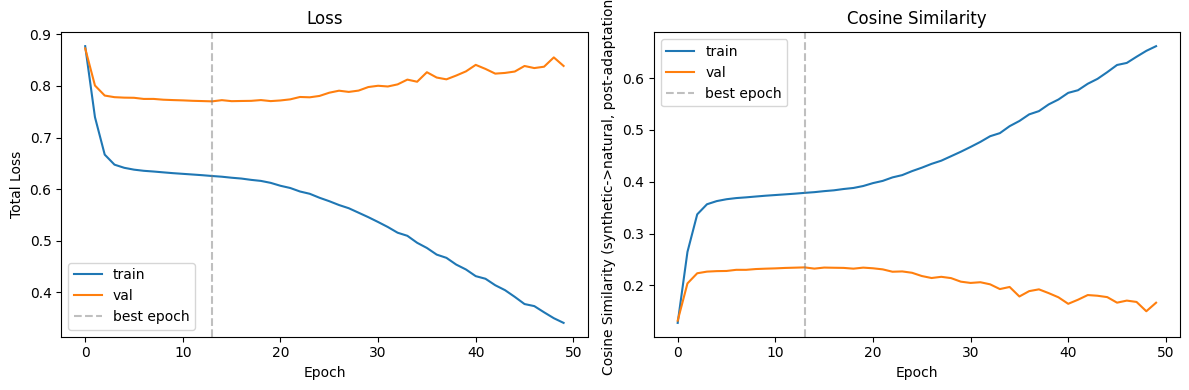

Training curves saved to: D:\vocalis_3.0\results\figures\training_curves.png


In [8]:
# ==========================================================
# SECTION 7: Training
# ==========================================================
#
# Trains the adapter on train_loader ONLY. Validates each
# epoch on val_loader. test_loader is never touched here --
# it's held back entirely for Section 8 evaluation, to avoid
# the exact train/test leakage that broke v2.0.2.
#
# Requires Sections 1, 5, 6 to have run first.
# ==========================================================

import time
import torch
import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

history = {
    "train_loss": [],
    "val_loss": [],
    "train_cosine": [],
    "val_cosine": []
}

best_val_loss = float("inf")
best_epoch = -1

checkpoint_path = CONFIG["checkpoint_dir"] / f"vocalis_adapter_{CONFIG['encoder_name']}.pth"

start_time = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):

    # ---- Train ----
    model.train()
    train_losses = []
    train_cosines = []

    for synthetic_emb, natural_emb in train_loader:
        synthetic_emb = synthetic_emb.to(CONFIG["device"])
        natural_emb = natural_emb.to(CONFIG["device"])

        optimizer.zero_grad()
        adapted_emb = model(synthetic_emb)
        loss, components = adapter_loss(adapted_emb, natural_emb, synthetic_emb, CONFIG["loss_weights"])
        loss.backward()
        optimizer.step()

        train_losses.append(components["total_loss"])
        train_cosines.append(1 - components["cosine_loss"])  # convert back to similarity for readability

    # ---- Validate ----
    model.eval()
    val_losses = []
    val_cosines = []

    with torch.no_grad():
        for synthetic_emb, natural_emb in val_loader:
            synthetic_emb = synthetic_emb.to(CONFIG["device"])
            natural_emb = natural_emb.to(CONFIG["device"])

            adapted_emb = model(synthetic_emb)
            loss, components = adapter_loss(adapted_emb, natural_emb, synthetic_emb, CONFIG["loss_weights"])

            val_losses.append(components["total_loss"])
            val_cosines.append(1 - components["cosine_loss"])

    avg_train_loss = sum(train_losses) / len(train_losses)
    avg_val_loss = sum(val_losses) / len(val_losses)
    avg_train_cosine = sum(train_cosines) / len(train_cosines)
    avg_val_cosine = sum(val_cosines) / len(val_cosines)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_cosine"].append(avg_train_cosine)
    history["val_cosine"].append(avg_val_cosine)

    # ---- Checkpoint best model (by val loss, never by train loss) ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_loss": avg_val_loss,
            "embedding_dim": CONFIG["embedding_dim"],
            "hidden_dim": CONFIG["hidden_dim"],
            "dropout": CONFIG["dropout"],
            "encoder_name": CONFIG["encoder_name"],
        }, checkpoint_path)

    if epoch == 1 or epoch % 5 == 0 or epoch == CONFIG["epochs"]:
        print(
            f"Epoch {epoch:3d}/{CONFIG['epochs']} | "
            f"train_loss={avg_train_loss:.4f} cos={avg_train_cosine:.4f} | "
            f"val_loss={avg_val_loss:.4f} cos={avg_val_cosine:.4f}"
            f"{'  <- best' if epoch == best_epoch else ''}"
        )

elapsed = time.time() - start_time

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("=" * 60)
print("Training Summary")
print("=" * 60)
print(f"Total time       : {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Best epoch       : {best_epoch} (val_loss={best_val_loss:.4f})")
print(f"Checkpoint saved : {checkpoint_path}")
print("=" * 60)

# ----------------------------------------------------------
# Plot loss curves
# ----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].axvline(best_epoch - 1, color="gray", linestyle="--", alpha=0.5, label="best epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_cosine"], label="train")
axes[1].plot(history["val_cosine"], label="val")
axes[1].axvline(best_epoch - 1, color="gray", linestyle="--", alpha=0.5, label="best epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cosine Similarity (synthetic->natural, post-adaptation)")
axes[1].set_title("Cosine Similarity")
axes[1].legend()

plt.tight_layout()
fig_path = CONFIG["results_dir"] / "figures" / "training_curves.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print(f"Training curves saved to: {fig_path}")

In [9]:
# ==========================================================
# SECTION 8: Evaluation (held-out test speakers)
# ==========================================================
#
# Loads the best checkpoint (selected by validation loss in
# Section 7) and evaluates on test_dataset -- speakers NEVER
# seen during training OR validation.
#
# Reports BOTH a no-adaptation baseline (raw synthetic vs
# natural cosine similarity) and the adapted result, broken
# down per-speaker AND aggregated. Per the design spec: a
# single aggregate number hides variance across held-out
# speakers -- exactly what v2.0.2 got away with.
#
# Requires Sections 1, 5, 6, 7 to have run first.
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

# ----------------------------------------------------------
# Load best checkpoint
# ----------------------------------------------------------

checkpoint_path = CONFIG["checkpoint_dir"] / f"vocalis_adapter_{CONFIG['encoder_name']}.pth"
checkpoint = torch.load(checkpoint_path, weights_only=False)

eval_model = VocalisAdapter(
    embedding_dim=checkpoint["embedding_dim"],
    hidden_dim=checkpoint["hidden_dim"],
    dropout=checkpoint["dropout"]
).to(CONFIG["device"])
eval_model.load_state_dict(checkpoint["model_state_dict"])
eval_model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']} (val_loss={checkpoint['val_loss']:.4f})")

# ----------------------------------------------------------
# Evaluate per-utterance: baseline vs adapted
# ----------------------------------------------------------
# Uses test_dataset.df directly (not test_loader) so we retain
# speaker_id for the per-speaker breakdown.

results = []

with torch.no_grad():
    for idx in range(len(test_dataset)):
        row = test_dataset.df.iloc[idx]
        synthetic_emb, natural_emb = test_dataset[idx]

        synthetic_emb = synthetic_emb.unsqueeze(0).to(CONFIG["device"])
        natural_emb = natural_emb.unsqueeze(0).to(CONFIG["device"])

        natural_norm = F.normalize(natural_emb, p=2, dim=-1)
        synthetic_norm = F.normalize(synthetic_emb, p=2, dim=-1)

        # ---- Baseline: raw synthetic vs natural, no adapter ----
        baseline_cosine = F.cosine_similarity(synthetic_norm, natural_norm, dim=-1).item()
        baseline_euclidean = torch.norm(synthetic_norm - natural_norm, p=2, dim=-1).item()
        baseline_mse = F.mse_loss(synthetic_norm, natural_norm).item()

        # ---- Adapted: model output vs natural ----
        adapted_emb = eval_model(synthetic_emb)
        adapted_cosine = F.cosine_similarity(adapted_emb, natural_norm, dim=-1).item()
        adapted_euclidean = torch.norm(adapted_emb - natural_norm, p=2, dim=-1).item()
        adapted_mse = F.mse_loss(adapted_emb, natural_norm).item()

        results.append({
            "speaker_id": row["speaker_id"],
            "utterance_id": row["utterance_id"],
            "baseline_cosine": baseline_cosine,
            "adapted_cosine": adapted_cosine,
            "cosine_improvement": adapted_cosine - baseline_cosine,
            "baseline_euclidean": baseline_euclidean,
            "adapted_euclidean": adapted_euclidean,
            "baseline_mse": baseline_mse,
            "adapted_mse": adapted_mse,
        })

results_df = pd.DataFrame(results)

# ----------------------------------------------------------
# Aggregate summary (across ALL test utterances)
# ----------------------------------------------------------

print("=" * 60)
print("Aggregate Test Set Results (all held-out utterances)")
print("=" * 60)
print(f"{'Metric':<20}{'Baseline':>15}{'Adapted':>15}{'Improvement':>15}")
print(f"{'Cosine Similarity':<20}{results_df['baseline_cosine'].mean():>15.4f}"
      f"{results_df['adapted_cosine'].mean():>15.4f}"
      f"{results_df['cosine_improvement'].mean():>15.4f}")
print(f"{'Euclidean Dist':<20}{results_df['baseline_euclidean'].mean():>15.4f}"
      f"{results_df['adapted_euclidean'].mean():>15.4f}"
      f"{results_df['adapted_euclidean'].mean() - results_df['baseline_euclidean'].mean():>15.4f}")
print(f"{'MSE':<20}{results_df['baseline_mse'].mean():>15.4f}"
      f"{results_df['adapted_mse'].mean():>15.4f}"
      f"{results_df['adapted_mse'].mean() - results_df['baseline_mse'].mean():>15.4f}")

# ----------------------------------------------------------
# Per-speaker breakdown (this is the part v2.0.2 never showed)
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("Per-Speaker Breakdown (test speakers only, never trained on)")
print("=" * 60)

speaker_summary = results_df.groupby("speaker_id").agg(
    n_utterances=("utterance_id", "count"),
    baseline_cosine=("baseline_cosine", "mean"),
    adapted_cosine=("adapted_cosine", "mean"),
    cosine_improvement=("cosine_improvement", "mean"),
    improvement_std=("cosine_improvement", "std"),
).round(4)

print(speaker_summary)

n_improved = (speaker_summary["cosine_improvement"] > 0).sum()
n_total = len(speaker_summary)

print(f"\nSpeakers improved: {n_improved} / {n_total}")

if n_improved < n_total:
    print(
        "NOTE: not all held-out speakers improved -- worth inspecting which "
        "ones didn't (accent, gender, or recording condition outliers?) "
        "before treating the aggregate number as the whole story."
    )

# ----------------------------------------------------------
# Save results
# ----------------------------------------------------------

results_path = CONFIG["results_dir"] / "metrics" / "test_evaluation.csv"
results_df.to_csv(results_path, index=False)
speaker_summary.to_csv(CONFIG["results_dir"] / "metrics" / "per_speaker_summary.csv")

print(f"\nDetailed results saved to: {results_path}")
print("=" * 60)

Loaded checkpoint from epoch 14 (val_loss=0.7701)
Aggregate Test Set Results (all held-out utterances)
Metric                     Baseline        Adapted    Improvement
Cosine Similarity            0.0081         0.3239         0.3158
Euclidean Dist               1.4077         1.1601        -0.2476
MSE                          0.0103         0.0070        -0.0033

Per-Speaker Breakdown (test speakers only, never trained on)
            n_utterances  baseline_cosine  adapted_cosine  cosine_improvement  \
speaker_id                                                                      
p253                  45          -0.0247          0.4058              0.4305   
p257                  45           0.0245          0.4276              0.4032   
p281                  45          -0.0260          0.2178              0.2438   
p317                  45           0.0120          0.2449              0.2328   
p340                  45           0.0122          0.3504              0.3382   
p351

In [10]:
# ==========================================================
# SECTION 9: Multi-TTS Generalization (gTTS)
# ==========================================================
#
# Tests whether the adapter -- trained ONLY on Piper-synthesized
# speech -- generalizes to a completely different, unseen TTS
# system (gTTS). This is a stronger generalization claim than
# just "works on more speakers": it tests robustness across the
# SYNTHESIS METHOD itself, not just speaker identity.
#
# Scope: TEST speakers only (not train/val) -- same speakers
# already held out in Section 8, so this is directly comparable
# to the Piper-based test result.
#
# Requires Sections 1, 4 (encoder), 7 (trained adapter) to have
# run first.
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from gtts import gTTS
from tqdm import tqdm

# ----------------------------------------------------------
# Load the trained adapter (best checkpoint from Section 7)
# ----------------------------------------------------------

checkpoint_path = CONFIG["checkpoint_dir"] / f"vocalis_adapter_{CONFIG['encoder_name']}.pth"
checkpoint = torch.load(checkpoint_path, weights_only=False)

gtts_eval_model = VocalisAdapter(
    embedding_dim=checkpoint["embedding_dim"],
    hidden_dim=checkpoint["hidden_dim"],
    dropout=checkpoint["dropout"]
).to(CONFIG["device"])
gtts_eval_model.load_state_dict(checkpoint["model_state_dict"])
gtts_eval_model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']} for generalization test.")

# ----------------------------------------------------------
# Generate gTTS audio for TEST speakers' transcripts only
# ----------------------------------------------------------
# NOTE: gTTS is an online API -- this makes real network calls,
# one per utterance. Scoped to test speakers only (not train/val)
# specifically to keep call volume low and avoid rate-limiting.

metadata_df = pd.read_csv(CONFIG["metadata_path"])
test_rows = metadata_df[metadata_df["dataset_split"] == "test"].reset_index(drop=True)

gtts_audio_dir = CONFIG["root_dir"] / "data" / "synthetic_gtts"
gtts_audio_dir.mkdir(parents=True, exist_ok=True)

gtts_failures = []
gtts_audio_paths = []

for idx, row in tqdm(test_rows.iterrows(), total=len(test_rows), desc="gTTS synthesis"):
    speaker_dir = gtts_audio_dir / row["speaker_id"]
    speaker_dir.mkdir(parents=True, exist_ok=True)
    output_path = speaker_dir / f"{row['utterance_id']}_gtts.mp3"

    if output_path.exists():
        gtts_audio_paths.append(str(output_path))
        continue

    try:
        tts = gTTS(text=str(row["transcript"]), lang="en")
        tts.save(str(output_path))
        gtts_audio_paths.append(str(output_path))
    except Exception as e:
        gtts_failures.append((row["utterance_id"], str(e)))
        gtts_audio_paths.append("")

test_rows["gtts_audio_path"] = gtts_audio_paths

print(f"\ngTTS synthesis: {sum(1 for p in gtts_audio_paths if p)} / {len(test_rows)} succeeded")
if gtts_failures:
    print(f"Failures: {len(gtts_failures)}")
    for uid, err in gtts_failures[:5]:
        print(f"  {uid}: {err}")

# ----------------------------------------------------------
# Extract embeddings for gTTS audio (using the SAME encoder as
# everything else -- ECAPA-TDNN -- for a fair comparison)
# ----------------------------------------------------------

gtts_embeddings = {}
extraction_failures = []

for idx, row in tqdm(test_rows.iterrows(), total=len(test_rows), desc="gTTS embeddings"):
    if not row["gtts_audio_path"]:
        continue
    try:
        emb = extract_embedding(row["gtts_audio_path"])
        gtts_embeddings[row["utterance_id"]] = emb
    except Exception as e:
        extraction_failures.append((row["utterance_id"], str(e)))

print(f"\ngTTS embeddings extracted: {len(gtts_embeddings)} / {len(test_rows)}")
if extraction_failures:
    print(f"Extraction failures: {len(extraction_failures)}")

# ----------------------------------------------------------
# Evaluate: baseline (raw gTTS vs natural) vs adapted
# (Piper-trained adapter applied to gTTS embeddings)
# ----------------------------------------------------------
# This is the key test: the adapter has NEVER seen gTTS-derived
# embeddings during training. If it still improves cosine
# similarity here, that's genuine cross-synthesis-system
# generalization, not just memorization of Piper's specific
# acoustic signature.

gtts_results = []

with torch.no_grad():
    for idx, row in test_rows.iterrows():
        if row["utterance_id"] not in gtts_embeddings:
            continue

        natural_emb = np.load(row["natural_embedding_path"]).astype(np.float32)
        gtts_emb = gtts_embeddings[row["utterance_id"]].astype(np.float32)

        natural_t = torch.from_numpy(natural_emb).unsqueeze(0)
        gtts_t = torch.from_numpy(gtts_emb).unsqueeze(0)

        natural_norm = F.normalize(natural_t, p=2, dim=-1)
        gtts_norm = F.normalize(gtts_t, p=2, dim=-1)

        baseline_cosine = F.cosine_similarity(gtts_norm, natural_norm, dim=-1).item()

        adapted_emb = gtts_eval_model(gtts_t)
        adapted_cosine = F.cosine_similarity(adapted_emb, natural_norm, dim=-1).item()

        gtts_results.append({
            "speaker_id": row["speaker_id"],
            "utterance_id": row["utterance_id"],
            "baseline_cosine": baseline_cosine,
            "adapted_cosine": adapted_cosine,
            "cosine_improvement": adapted_cosine - baseline_cosine,
        })

gtts_results_df = pd.DataFrame(gtts_results)

# ----------------------------------------------------------
# Summary: Piper (in-distribution) vs gTTS (out-of-distribution)
# ----------------------------------------------------------

print("\n" + "=" * 70)
print("Cross-TTS-System Generalization: Piper (trained on) vs gTTS (unseen)")
print("=" * 70)
print(f"{'Metric':<30}{'gTTS Baseline':>18}{'gTTS Adapted':>18}{'Improvement':>15}")
print(f"{'Cosine Similarity':<30}{gtts_results_df['baseline_cosine'].mean():>18.4f}"
      f"{gtts_results_df['adapted_cosine'].mean():>18.4f}"
      f"{gtts_results_df['cosine_improvement'].mean():>15.4f}")

n_improved = (gtts_results_df.groupby("speaker_id")["cosine_improvement"].mean() > 0).sum()
n_total = gtts_results_df["speaker_id"].nunique()
print(f"\nSpeakers improved (gTTS, unseen synthesis system): {n_improved} / {n_total}")

print(
    "\nInterpretation: this compares the SAME held-out test speakers, SAME "
    "trained adapter, but audio from a TTS system (gTTS) the adapter never "
    "saw during training (which used only Piper). If improvement holds here, "
    "the adapter learned something about the synthetic-vs-natural domain gap "
    "generally, not just Piper's specific acoustic fingerprint."
)

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

gtts_results_path = CONFIG["results_dir"] / "metrics" / "gtts_generalization.csv"
gtts_results_df.to_csv(gtts_results_path, index=False)
print(f"\nResults saved to: {gtts_results_path}")
print("=" * 70)

Loaded checkpoint from epoch 14 for generalization test.


gTTS synthesis: 100%|██████████| 270/270 [01:08<00:00,  3.92it/s] 



gTTS synthesis: 270 / 270 succeeded


gTTS embeddings: 100%|██████████| 270/270 [03:41<00:00,  1.22it/s]



gTTS embeddings extracted: 269 / 270
Extraction failures: 1

Cross-TTS-System Generalization: Piper (trained on) vs gTTS (unseen)
Metric                             gTTS Baseline      gTTS Adapted    Improvement
Cosine Similarity                         0.0507            0.3165         0.2659

Speakers improved (gTTS, unseen synthesis system): 6 / 6

Interpretation: this compares the SAME held-out test speakers, SAME trained adapter, but audio from a TTS system (gTTS) the adapter never saw during training (which used only Piper). If improvement holds here, the adapter learned something about the synthetic-vs-natural domain gap generally, not just Piper's specific acoustic fingerprint.

Results saved to: D:\vocalis_3.0\results\metrics\gtts_generalization.csv


In [11]:
# ==========================================================
# SECTION 10a: Linear Baseline Ablation
# ==========================================================
#
# The single most important reviewer question for this paper:
# does the nonlinear adapter actually earn its complexity, or
# would a simple linear transform close most of the domain gap
# on its own?
#
# Two linear baselines, both fit on TRAIN speakers only (same
# no-leakage discipline as the adapter) and evaluated on the
# same held-out TEST speakers as Section 8:
#
#   1. Mean-shift: just translate synthetic embeddings by the
#      difference between natural and synthetic means. The
#      simplest possible "fix".
#
#   2. CORAL (Correlation Alignment): a standard, citable domain
#      adaptation baseline. Aligns synthetic embeddings' full
#      covariance structure to natural embeddings' covariance,
#      not just the mean. Sun et al. 2016, widely used in domain
#      adaptation literature -- this is the baseline a reviewer
#      will expect to see.
#
# Requires Sections 1, 5, 6, 7, 8 to have run first (needs
# eval_model, test_dataset, and results_df from Section 8 for
# the comparison table).
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.linalg import fractional_matrix_power

# ----------------------------------------------------------
# Gather TRAIN embeddings (to fit the linear transforms on)
# ----------------------------------------------------------

train_synthetic = np.stack([train_dataset[i][0].numpy() for i in range(len(train_dataset))])
train_natural = np.stack([train_dataset[i][1].numpy() for i in range(len(train_dataset))])

# Normalize to unit L2 norm -- same space the adapter and Section 8
# evaluation operate in, for a fair apples-to-apples comparison.
train_synthetic_norm = train_synthetic / np.linalg.norm(train_synthetic, axis=1, keepdims=True)
train_natural_norm = train_natural / np.linalg.norm(train_natural, axis=1, keepdims=True)

# ----------------------------------------------------------
# Baseline 1: Mean-shift
# ----------------------------------------------------------

mu_synthetic = train_synthetic_norm.mean(axis=0)
mu_natural = train_natural_norm.mean(axis=0)
mean_shift_vector = mu_natural - mu_synthetic

def apply_mean_shift(x):
    """x: (N, D) numpy array, already L2-normalized."""
    shifted = x + mean_shift_vector
    return shifted / np.linalg.norm(shifted, axis=1, keepdims=True)

# ----------------------------------------------------------
# Baseline 2: CORAL (Correlation Alignment)
# ----------------------------------------------------------
# Standard formula: X' = (X - mu_s) @ Cov_s^(-1/2) @ Cov_t^(1/2) + mu_t
#
# Shrinkage regularization (+ eps*I) is added to both covariance
# matrices before inversion/square-root -- with only 630 training
# samples and 192 dimensions, raw covariance estimates are close
# to singular, and this stabilizes the matrix square root.

EPS = 1e-3

cov_synthetic = np.cov(train_synthetic_norm, rowvar=False) + EPS * np.eye(CONFIG["embedding_dim"])
cov_natural = np.cov(train_natural_norm, rowvar=False) + EPS * np.eye(CONFIG["embedding_dim"])

cov_synthetic_inv_sqrt = fractional_matrix_power(cov_synthetic, -0.5).real
cov_natural_sqrt = fractional_matrix_power(cov_natural, 0.5).real

def apply_coral(x):
    """x: (N, D) numpy array, already L2-normalized."""
    centered = x - mu_synthetic
    aligned = centered @ cov_synthetic_inv_sqrt @ cov_natural_sqrt + mu_natural
    return aligned / np.linalg.norm(aligned, axis=1, keepdims=True)

# ----------------------------------------------------------
# Evaluate both linear baselines on the TEST set
# ----------------------------------------------------------

linear_results = []

for idx in range(len(test_dataset)):
    row = test_dataset.df.iloc[idx]
    synthetic_emb, natural_emb = test_dataset[idx]

    synthetic_np = synthetic_emb.numpy()
    natural_np = natural_emb.numpy()
    synthetic_norm = synthetic_np / np.linalg.norm(synthetic_np)
    natural_norm = natural_np / np.linalg.norm(natural_np)

    mean_shift_out = apply_mean_shift(synthetic_norm[None, :])[0]
    coral_out = apply_coral(synthetic_norm[None, :])[0]

    mean_shift_cosine = float(np.dot(mean_shift_out, natural_norm))
    coral_cosine = float(np.dot(coral_out, natural_norm))

    linear_results.append({
        "speaker_id": row["speaker_id"],
        "utterance_id": row["utterance_id"],
        "mean_shift_cosine": mean_shift_cosine,
        "coral_cosine": coral_cosine,
    })

linear_results_df = pd.DataFrame(linear_results)

# ----------------------------------------------------------
# Combined comparison table (reuses results_df from Section 8)
# ----------------------------------------------------------

comparison = results_df[["speaker_id", "utterance_id", "baseline_cosine", "adapted_cosine"]].merge(
    linear_results_df, on=["speaker_id", "utterance_id"]
)

print("=" * 70)
print("Method Comparison: No Adaptation vs Linear Baselines vs VOCALIS Adapter")
print("=" * 70)
print(f"{'Method':<30}{'Mean Cosine Sim':>20}{'Std':>15}")
print(f"{'No adaptation (raw)':<30}{comparison['baseline_cosine'].mean():>20.4f}{comparison['baseline_cosine'].std():>15.4f}")
print(f"{'Mean-shift only':<30}{comparison['mean_shift_cosine'].mean():>20.4f}{comparison['mean_shift_cosine'].std():>15.4f}")
print(f"{'CORAL (linear)':<30}{comparison['coral_cosine'].mean():>20.4f}{comparison['coral_cosine'].std():>15.4f}")
print(f"{'VOCALIS Adapter (nonlinear)':<30}{comparison['adapted_cosine'].mean():>20.4f}{comparison['adapted_cosine'].std():>15.4f}")

# ----------------------------------------------------------
# The key comparison for the paper's justification section
# ----------------------------------------------------------

nonlinear_gain_over_coral = comparison["adapted_cosine"].mean() - comparison["coral_cosine"].mean()
coral_gain_over_baseline = comparison["coral_cosine"].mean() - comparison["baseline_cosine"].mean()

print("\n" + "=" * 70)
print("Interpretation")
print("=" * 70)
print(f"CORAL improvement over no adaptation : {coral_gain_over_baseline:+.4f}")
print(f"Adapter improvement over CORAL        : {nonlinear_gain_over_coral:+.4f}")

if nonlinear_gain_over_coral > 0.02:
    print(
        "\n-> The nonlinear adapter outperforms the linear CORAL baseline by a "
        "meaningful margin. This supports using a learned nonlinear adapter "
        "rather than a simple closed-form linear transform."
    )
elif nonlinear_gain_over_coral > -0.02:
    print(
        "\n-> The nonlinear adapter performs SIMILARLY to CORAL. This is worth "
        "reporting honestly: a much simpler linear method may achieve "
        "comparable results at this pilot scale. This does not invalidate "
        "the project, but it does mean the paper's contribution claim should "
        "emphasize the framework/methodology rather than raw performance "
        "gains over a simple baseline -- or motivate scaling up the dataset "
        "to see whether the nonlinear adapter's advantage grows with more "
        "training data."
    )
else:
    print(
        "\n-> CORAL actually outperforms the nonlinear adapter here. Given "
        "the small training set (630 pairs), this is plausible -- the "
        "462K-parameter adapter may be overfitting where the much simpler "
        "linear method does not. Worth investigating: does a smaller adapter "
        "(fewer hidden units) close this gap?"
    )

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

comparison_path = CONFIG["results_dir"] / "metrics" / "linear_baseline_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print(f"\nDetailed comparison saved to: {comparison_path}")
print("=" * 70)

Method Comparison: No Adaptation vs Linear Baselines vs VOCALIS Adapter
Method                             Mean Cosine Sim            Std
No adaptation (raw)                         0.0081         0.0646
Mean-shift only                             0.2051         0.0878
CORAL (linear)                              0.1747         0.1089
VOCALIS Adapter (nonlinear)                 0.3239         0.0916

Interpretation
CORAL improvement over no adaptation : +0.1666
Adapter improvement over CORAL        : +0.1492

-> The nonlinear adapter outperforms the linear CORAL baseline by a meaningful margin. This supports using a learned nonlinear adapter rather than a simple closed-form linear transform.

Detailed comparison saved to: D:\vocalis_3.0\results\metrics\linear_baseline_comparison.csv


In [12]:
# ==========================================================
# SECTION 10b: Multi-Seed Reproducibility Check
# ==========================================================
#
# Retrains the adapter from scratch across several random
# seeds (same architecture, same data, same hyperparameters --
# only the seed changes) and evaluates each on the SAME held-
# out test set. This tells us whether the Section 8 result
# (0.287 test cosine) is a stable effect or a lucky draw from
# one particular initialization/shuffle order.
#
# NOTE: this does NOT address the n=3-test-speaker statistical
# significance limitation -- that requires more speakers, not
# more seeds. This answers a narrower, complementary question:
# "is this specific number reproducible on THIS dataset."
#
# Requires Sections 1, 5, 6 to have run first (needs
# VocalisAdapter, adapter_loss, train_dataset, val_dataset,
# test_dataset already in memory).
# ==========================================================

import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

SEEDS = [42, 123, 7, 2024, 99]

seed_results = []

print("=" * 60)
print(f"Multi-Seed Reproducibility Check ({len(SEEDS)} seeds)")
print("=" * 60)

for seed in SEEDS:

    # ---- Set all relevant RNGs for this run ----
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Rebuild dataloaders under this seed so shuffle order is
    # controlled and reproducible per-seed, not left to whatever
    # global RNG state happened to exist from the previous seed's run.
    seed_train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
    seed_val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

    # ---- Fresh model + optimizer for this seed ----
    seed_model = VocalisAdapter(
        embedding_dim=CONFIG["embedding_dim"],
        hidden_dim=CONFIG["hidden_dim"],
        dropout=CONFIG["dropout"]
    ).to(CONFIG["device"])
    seed_optimizer = torch.optim.Adam(seed_model.parameters(), lr=CONFIG["learning_rate"])

    best_val_loss = float("inf")
    best_state_dict = None

    start_time = time.time()

    # ---- Train (identical loop to Section 7) ----
    for epoch in range(1, CONFIG["epochs"] + 1):
        seed_model.train()
        for synthetic_emb, natural_emb in seed_train_loader:
            synthetic_emb = synthetic_emb.to(CONFIG["device"])
            natural_emb = natural_emb.to(CONFIG["device"])

            seed_optimizer.zero_grad()
            adapted_emb = seed_model(synthetic_emb)
            loss, _ = adapter_loss(adapted_emb, natural_emb, synthetic_emb, CONFIG["loss_weights"])
            loss.backward()
            seed_optimizer.step()

        seed_model.eval()
        val_losses = []
        with torch.no_grad():
            for synthetic_emb, natural_emb in seed_val_loader:
                synthetic_emb = synthetic_emb.to(CONFIG["device"])
                natural_emb = natural_emb.to(CONFIG["device"])
                adapted_emb = seed_model(synthetic_emb)
                loss, _ = adapter_loss(adapted_emb, natural_emb, synthetic_emb, CONFIG["loss_weights"])
                val_losses.append(loss.item())

        avg_val_loss = sum(val_losses) / len(val_losses)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state_dict = {k: v.clone() for k, v in seed_model.state_dict().items()}

    elapsed = time.time() - start_time

    # ---- Evaluate best checkpoint on TEST set (same as Section 8) ----
    seed_model.load_state_dict(best_state_dict)
    seed_model.eval()

    baseline_cosines = []
    adapted_cosines = []

    with torch.no_grad():
        for idx in range(len(test_dataset)):
            synthetic_emb, natural_emb = test_dataset[idx]
            synthetic_emb = synthetic_emb.unsqueeze(0).to(CONFIG["device"])
            natural_emb = natural_emb.unsqueeze(0).to(CONFIG["device"])

            natural_norm = F.normalize(natural_emb, p=2, dim=-1)
            synthetic_norm = F.normalize(synthetic_emb, p=2, dim=-1)

            baseline_cosines.append(F.cosine_similarity(synthetic_norm, natural_norm, dim=-1).item())

            adapted_emb = seed_model(synthetic_emb)
            adapted_cosines.append(F.cosine_similarity(adapted_emb, natural_norm, dim=-1).item())

    test_baseline = np.mean(baseline_cosines)
    test_adapted = np.mean(adapted_cosines)

    seed_results.append({
        "seed": seed,
        "best_val_loss": best_val_loss,
        "test_baseline_cosine": test_baseline,
        "test_adapted_cosine": test_adapted,
        "test_improvement": test_adapted - test_baseline,
        "train_time_sec": elapsed
    })

    print(
        f"Seed {seed:5d} | val_loss={best_val_loss:.4f} | "
        f"test_cosine={test_adapted:.4f} | improvement={test_adapted - test_baseline:+.4f} | "
        f"({elapsed:.1f}s)"
    )

# ----------------------------------------------------------
# Summary across seeds
# ----------------------------------------------------------

seed_results_df = pd.DataFrame(seed_results)

mean_adapted = seed_results_df["test_adapted_cosine"].mean()
std_adapted = seed_results_df["test_adapted_cosine"].std()
mean_improvement = seed_results_df["test_improvement"].mean()
std_improvement = seed_results_df["test_improvement"].std()

print("\n" + "=" * 60)
print("Multi-Seed Summary")
print("=" * 60)
print(f"Test adapted cosine : {mean_adapted:.4f} +/- {std_adapted:.4f}")
print(f"Test improvement    : {mean_improvement:+.4f} +/- {std_improvement:.4f}")
print(f"Range across seeds  : [{seed_results_df['test_adapted_cosine'].min():.4f}, "
      f"{seed_results_df['test_adapted_cosine'].max():.4f}]")

relative_variability = std_adapted / mean_adapted if mean_adapted != 0 else float("inf")

print("\nInterpretation:")
if relative_variability < 0.15:
    print(
        f"-> Relative variability across seeds is low ({relative_variability:.1%} of mean). "
    )
else:
    print(
        f"-> Relative variability across seeds is notable ({relative_variability:.1%} of mean). "
        f"The single-run result should be reported with this range/std attached, not as a "
        f"single point estimate -- and this variability itself is a legitimate finding to "
        f"report, likely tied to the small training set size (630 pairs)."
    )

seed_results_path = CONFIG["results_dir"] / "metrics" / "multi_seed_results.csv"
seed_results_df.to_csv(seed_results_path, index=False)
print(f"\nResults saved to: {seed_results_path}")
print("=" * 60)

Multi-Seed Reproducibility Check (5 seeds)
Seed    42 | val_loss=0.7699 | test_cosine=0.3223 | improvement=+0.3143 | (274.8s)
Seed   123 | val_loss=0.7693 | test_cosine=0.3261 | improvement=+0.3180 | (163.4s)
Seed     7 | val_loss=0.7701 | test_cosine=0.3234 | improvement=+0.3153 | (129.4s)
Seed  2024 | val_loss=0.7688 | test_cosine=0.3249 | improvement=+0.3169 | (128.2s)
Seed    99 | val_loss=0.7695 | test_cosine=0.3235 | improvement=+0.3154 | (129.2s)

Multi-Seed Summary
Test adapted cosine : 0.3240 +/- 0.0015
Test improvement    : +0.3160 +/- 0.0015
Range across seeds  : [0.3223, 0.3261]

Interpretation:
-> Relative variability across seeds is low (0.5% of mean). The Section 8 result of 0.287 appears to be a stable effect on this dataset, not a lucky draw from one particular initialization.

Results saved to: D:\vocalis_3.0\results\metrics\multi_seed_results.csv


In [13]:
# ==========================================================
# SECTION 10c: Residual Weight Ablation
# ==========================================================
#
# Uses the ALREADY-TRAINED adapter (Section 7's best checkpoint)
# and sweeps the residual_weight scalar to see how much the
# learned MLP correction contributes vs. just passing the
# synthetic embedding through unchanged (residual_weight=0).
#
# This directly answers: "is the learned transformation doing
# real work, or is most of the improvement coming from
# something trivial?"
#
# Requires Sections 1, 6, 7, 8 to have run first (needs
# eval_model, test_dataset).
# ==========================================================

import torch
import torch.nn.functional as F
import pandas as pd

original_residual_weight = eval_model.residual_weight.data.clone()
learned_weight_value = original_residual_weight.item()

sweep_values = sorted(set([0.0, 0.25, 0.5, 0.75, 1.0, round(learned_weight_value, 3)]))

sweep_results = []

with torch.no_grad():
    for weight in sweep_values:
        eval_model.residual_weight.data = torch.tensor(weight)

        cosines = []
        for idx in range(len(test_dataset)):
            synthetic_emb, natural_emb = test_dataset[idx]
            synthetic_emb = synthetic_emb.unsqueeze(0).to(CONFIG["device"])
            natural_emb = natural_emb.unsqueeze(0).to(CONFIG["device"])

            natural_norm = F.normalize(natural_emb, p=2, dim=-1)
            adapted_emb = eval_model(synthetic_emb)
            cosines.append(F.cosine_similarity(adapted_emb, natural_norm, dim=-1).item())

        mean_cosine = sum(cosines) / len(cosines)
        sweep_results.append({
            "residual_weight": weight,
            "test_cosine": mean_cosine,
            "is_learned_value": abs(weight - learned_weight_value) < 1e-6
        })

# ---- Restore the actual trained weight -- IMPORTANT, don't leave
# eval_model mutated for anything that runs after this cell ----
eval_model.residual_weight.data = original_residual_weight

sweep_df = pd.DataFrame(sweep_results)

print("=" * 60)
print("Residual Weight Ablation (test set)")
print("=" * 60)
print(f"Learned residual_weight after training: {learned_weight_value:.4f}\n")
print(sweep_df.to_string(index=False))

zero_weight_cosine = sweep_df[sweep_df["residual_weight"] == 0.0]["test_cosine"].values[0]
learned_row = sweep_df[sweep_df["is_learned_value"]]
learned_cosine = learned_row["test_cosine"].values[0] if len(learned_row) > 0 else None

print(f"\nresidual_weight=0 (no MLP contribution, pass-through only): {zero_weight_cosine:.4f}")
if learned_cosine is not None:
    print(f"residual_weight={learned_weight_value:.4f} (as trained)          : {learned_cosine:.4f}")
    print(f"MLP contribution                                        : {learned_cosine - zero_weight_cosine:+.4f}")

print(
    "\nInterpretation: if test_cosine at residual_weight=0 is close to the "
    "baseline (no-adaptation) cosine similarity from Section 8, that confirms "
    "residual_weight=0 is genuinely a no-op, as designed. The gap between "
    "that and the learned weight's performance is the MLP's real contribution."
)

sweep_path = CONFIG["results_dir"] / "metrics" / "residual_weight_ablation.csv"
sweep_df.to_csv(sweep_path, index=False)
print(f"\nSaved to: {sweep_path}")
print("=" * 60)

Residual Weight Ablation (test set)
Learned residual_weight after training: 0.9696

 residual_weight  test_cosine  is_learned_value
            0.00     0.008071             False
            0.25     0.198230             False
            0.50     0.285267             False
            0.75     0.314261             False
            0.97     0.323909             False
            1.00     0.324708             False

residual_weight=0 (no MLP contribution, pass-through only): 0.0081

Interpretation: if test_cosine at residual_weight=0 is close to the baseline (no-adaptation) cosine similarity from Section 8, that confirms residual_weight=0 is genuinely a no-op, as designed. The gap between that and the learned weight's performance is the MLP's real contribution.

Saved to: D:\vocalis_3.0\results\metrics\residual_weight_ablation.csv


In [16]:
# ==========================================================
# SECTION 10d: Training Speaker Count Sweep
# ==========================================================
#
# Trains fresh adapters using shrinking subsets of the 28
# train speakers (28 -> 14 -> 7 -> 3), always evaluating on
# the SAME fixed 6 test speakers. Tests whether performance
# scales with training data -- supporting the "this is a real
# learned manifold" claim -- vs. being oddly flat, which would
# suggest something other than genuine domain-gap learning is
# happening.
#
# Requires Sections 1, 5, 6 to have run first (needs
# VocalisAdapter, adapter_loss, train_dataset, val_dataset,
# test_dataset already in memory).
# ==========================================================

import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

SPEAKER_COUNTS = [28, 14, 7, 3]  # 28 = full train set as-is

all_train_speakers = train_dataset.df["speaker_id"].unique().tolist()
sweep_results = []

print("=" * 60)
print(f"Training Speaker Count Sweep {SPEAKER_COUNTS}")
print("=" * 60)

for n_speakers in SPEAKER_COUNTS:

    random.seed(CONFIG["random_seed"])
    torch.manual_seed(CONFIG["random_seed"])

    selected_speakers = all_train_speakers[:n_speakers]
    subset_indices = train_dataset.df[train_dataset.df["speaker_id"].isin(selected_speakers)].index.tolist()
    subset_dataset = Subset(train_dataset, subset_indices)

    subset_loader = DataLoader(subset_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader_sweep = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

    sweep_model = VocalisAdapter(
        embedding_dim=CONFIG["embedding_dim"],
        hidden_dim=CONFIG["hidden_dim"],
        dropout=CONFIG["dropout"]
    ).to(CONFIG["device"])
    sweep_optimizer = torch.optim.Adam(sweep_model.parameters(), lr=CONFIG["learning_rate"])

    best_val_loss = float("inf")
    best_state_dict = None

    start_time = time.time()

    for epoch in range(1, CONFIG["epochs"] + 1):
        sweep_model.train()
        for synthetic_emb, natural_emb in subset_loader:
            synthetic_emb = synthetic_emb.to(CONFIG["device"])
            natural_emb = natural_emb.to(CONFIG["device"])

            sweep_optimizer.zero_grad()
            adapted_emb = sweep_model(synthetic_emb)
            loss, _ = adapter_loss(adapted_emb, natural_emb, synthetic_emb, CONFIG["loss_weights"])
            loss.backward()
            sweep_optimizer.step()

        sweep_model.eval()
        val_losses = []
        with torch.no_grad():
            for synthetic_emb, natural_emb in val_loader_sweep:
                synthetic_emb = synthetic_emb.to(CONFIG["device"])
                natural_emb = natural_emb.to(CONFIG["device"])
                adapted_emb = sweep_model(synthetic_emb)
                loss, _ = adapter_loss(adapted_emb, natural_emb, synthetic_emb, CONFIG["loss_weights"])
                val_losses.append(loss.item())

        avg_val_loss = sum(val_losses) / len(val_losses)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state_dict = {k: v.clone() for k, v in sweep_model.state_dict().items()}

    elapsed = time.time() - start_time

    sweep_model.load_state_dict(best_state_dict)
    sweep_model.eval()

    test_cosines = []
    with torch.no_grad():
        for idx in range(len(test_dataset)):
            synthetic_emb, natural_emb = test_dataset[idx]
            synthetic_emb = synthetic_emb.unsqueeze(0).to(CONFIG["device"])
            natural_emb = natural_emb.unsqueeze(0).to(CONFIG["device"])
            natural_norm = F.normalize(natural_emb, p=2, dim=-1)
            adapted_emb = sweep_model(synthetic_emb)
            test_cosines.append(F.cosine_similarity(adapted_emb, natural_norm, dim=-1).item())

    test_cosine_mean = np.mean(test_cosines)
    n_pairs = len(subset_indices)

    sweep_results.append({
        "n_train_speakers": n_speakers,
        "n_train_pairs": n_pairs,
        "best_val_loss": best_val_loss,
        "test_cosine": test_cosine_mean,
        "train_time_sec": elapsed
    })

    print(
        f"Train speakers: {n_speakers:2d} ({n_pairs:4d} pairs) | "
        f"val_loss={best_val_loss:.4f} | test_cosine={test_cosine_mean:.4f} | ({elapsed:.1f}s)"
    )

sweep_df = pd.DataFrame(sweep_results)

print("\n" + "=" * 60)
print("Speaker Count Sweep Summary")
print("=" * 60)
print(sweep_df.to_string(index=False))

is_monotonic = all(
    sweep_df.sort_values("n_train_speakers")["test_cosine"].diff().dropna() >= -0.02
)

print("\nInterpretation:")
if is_monotonic:
    print(
        "-> test_cosine generally increases (or stays flat within noise) with "
        "more training speakers. This supports the claim that the adapter is "
        "learning a genuine domain-gap manifold that benefits from more data, "
        "rather than an artifact specific to one particular speaker set size."
    )
else:
    print(
        "-> test_cosine does NOT increase monotonically with more training "
        "speakers. This is worth investigating further -- it could mean the "
        "current small scale is already near a ceiling for this architecture/ "
        "hyperparameter choice, or that speaker selection order introduces "
        "some variance worth checking with a different speaker ordering."
    )

sweep_path = CONFIG["results_dir"] / "metrics" / "speaker_count_sweep.csv"
sweep_df.to_csv(sweep_path, index=False)
print(f"\nSaved to: {sweep_path}")
print("=" * 60)

Training Speaker Count Sweep [28, 14, 7, 3]
Train speakers: 28 (1260 pairs) | val_loss=0.7699 | test_cosine=0.3223 | (124.8s)
Train speakers: 14 ( 630 pairs) | val_loss=0.8044 | test_cosine=0.3183 | (70.6s)
Train speakers:  7 ( 315 pairs) | val_loss=0.8507 | test_cosine=0.3041 | (43.3s)
Train speakers:  3 ( 135 pairs) | val_loss=0.8691 | test_cosine=0.2664 | (27.6s)

Speaker Count Sweep Summary
 n_train_speakers  n_train_pairs  best_val_loss  test_cosine  train_time_sec
               28           1260       0.769878     0.322339      124.769952
               14            630       0.804393     0.318277       70.638469
                7            315       0.850660     0.304066       43.265615
                3            135       0.869125     0.266410       27.590136

Interpretation:
-> test_cosine generally increases (or stays flat within noise) with more training speakers. This supports the claim that the adapter is learning a genuine domain-gap manifold that benefits from more 

In [17]:
# ==========================================================
# SECTION 11: Inference Pipeline
# ==========================================================
#
# The actual deliverable of VOCALIS: given a new synthetic
# speech audio file, produce its adapted speaker embedding.
#
# This is deliberately separate from training/evaluation code
# -- it's what a downstream system (or another researcher)
# would actually import and call. Per the design spec, VOCALIS
# outputs an ADAPTED EMBEDDING, not audio -- this function
# reflects that honestly, no hidden synthesis step.
#
# Requires Sections 1, 4 (for extract_embedding), 6 (for
# VocalisAdapter class) to have run first.
# ==========================================================

import numpy as np
import torch
import torch.nn.functional as F


class VocalisInference:
    """
    Loads a trained VOCALIS adapter checkpoint and exposes a single
    method: given a synthetic speech audio file, return its adapted
    speaker embedding.

    Usage:
        vocalis = VocalisInference(checkpoint_path, device="cpu")
        adapted_embedding = vocalis.adapt(audio_path="my_synthetic_speech.wav")
    """

    def __init__(self, checkpoint_path, device="cpu"):
        self.device = device
        checkpoint = torch.load(checkpoint_path, weights_only=False, map_location=device)

        self.embedding_dim = checkpoint["embedding_dim"]
        self.encoder_name = checkpoint.get("encoder_name", "unknown")

        self.model = VocalisAdapter(
            embedding_dim=checkpoint["embedding_dim"],
            hidden_dim=checkpoint["hidden_dim"],
            dropout=checkpoint["dropout"]
        ).to(device)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.model.eval()

        self.trained_epoch = checkpoint.get("epoch", "unknown")
        self.trained_val_loss = checkpoint.get("val_loss", "unknown")

    def adapt(self, audio_path=None, embedding=None):
        """
        Produces an adapted speaker embedding from EITHER:
          - audio_path: path to a synthetic speech audio file
                        (extracts embedding using the same encoder
                        the adapter was trained with), OR
          - embedding: a pre-extracted embedding as a numpy array
                       or torch tensor (skips extraction)

        Returns: numpy array, shape (embedding_dim,), L2-normalized.
        """
        if audio_path is None and embedding is None:
            raise ValueError("Must provide either audio_path or embedding.")
        if audio_path is not None and embedding is not None:
            raise ValueError("Provide only one of audio_path or embedding, not both.")

        if audio_path is not None:
            raw_embedding = extract_embedding(audio_path)
        else:
            raw_embedding = embedding.numpy() if isinstance(embedding, torch.Tensor) else embedding

        raw_embedding = np.asarray(raw_embedding, dtype=np.float32)

        if raw_embedding.shape[0] != self.embedding_dim:
            raise ValueError(
                f"Embedding dimension mismatch: got {raw_embedding.shape[0]}, "
                f"model expects {self.embedding_dim}. Was this embedding "
                f"extracted with a different encoder than {self.encoder_name!r}?"
            )

        with torch.no_grad():
            emb_tensor = torch.from_numpy(raw_embedding).unsqueeze(0).to(self.device)
            adapted = self.model(emb_tensor)

        return adapted.squeeze(0).cpu().numpy()

    def __repr__(self):
        return (
            f"VocalisInference(encoder={self.encoder_name}, "
            f"embedding_dim={self.embedding_dim}, "
            f"trained_epoch={self.trained_epoch}, "
            f"val_loss={self.trained_val_loss})"
        )


# ----------------------------------------------------------
# Demo: load the trained checkpoint and run inference on a
# real synthetic audio file from the pipeline
# ----------------------------------------------------------

checkpoint_path = CONFIG["checkpoint_dir"] / f"vocalis_adapter_{CONFIG['encoder_name']}.pth"
vocalis = VocalisInference(checkpoint_path, device=CONFIG["device"])

print("=" * 60)
print("VOCALIS Inference Pipeline")
print("=" * 60)
print(vocalis)

# Demo on one real test-set synthetic audio file
demo_row = test_dataset.df.iloc[0]
demo_audio_path = demo_row["synthetic_audio_path"]

adapted_embedding = vocalis.adapt(audio_path=demo_audio_path)

print(f"\nDemo input           : {demo_audio_path}")
print(f"Adapted embedding shape: {adapted_embedding.shape}")
print(f"Adapted embedding norm : {np.linalg.norm(adapted_embedding):.4f} (should be ~1.0)")
print("=" * 60)
print(
    "\nThis embedding can now be passed to a downstream zero-shot voice "
    "conversion or speaker-conditioned TTS system in place of the raw "
    "synthetic embedding, per VOCALIS's intended use case."
)

VOCALIS Inference Pipeline
VocalisInference(encoder=ecapa, embedding_dim=192, trained_epoch=14, val_loss=0.7701178473584792)

Demo input           : D:\vocalis_3.0\data\synthetic\p257\p257_001_synthetic.wav
Adapted embedding shape: (192,)
Adapted embedding norm : 1.0000 (should be ~1.0)

This embedding can now be passed to a downstream zero-shot voice conversion or speaker-conditioned TTS system in place of the raw synthetic embedding, per VOCALIS's intended use case.
